In [72]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import matplotlib.pyplot as plt

In [73]:
# ------------------------------------------------------------------
# 1) SET RANDOM SEEDS FOR REPRODUCIBILITY
# ------------------------------------------------------------------
seed_val = 42
np.random.seed(seed_val)
torch.manual_seed(seed_val)

In [74]:
# ------------------------------------------------------------------
# 2) LOAD AND PREPROCESS THE DATA
# ------------------------------------------------------------------
data = pd.read_csv('../../../data/resample_minmax_all.csv')

# ✅ Extract IDs and target columns
data_id = data["apogee_id"]
data_target = data[["TEFF", "J", "H", "K", "LOGG"]]

# ✅ Drop unused columns (ID and targets)
columns_to_drop = ["apogee_id", "TEFF", "J", "H", "K", "LOGG"]
data = data.drop(columns=columns_to_drop)

print("✅ Data Loaded and Preprocessed Successfully!")
print(f"🆔 ID Columns: {data_id.shape}")
print(f"🎯 Target Columns: {data_target.shape}")
print(data.columns)

# Convert to float32 and reset the index
data = data.astype('float32').reset_index(drop=True)
print("Final Data Shape :", data.shape)


✅ Data Loaded and Preprocessed Successfully!
🆔 ID Columns: (175770,)
🎯 Target Columns: (175770, 5)
Index(['C_FE', 'CI_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE',
       'S_FE', 'K_FE', 'CA_FE', 'TI_FE', 'V_FE', 'CR_FE', 'MN_FE', 'NI_FE',
       'FE_H'],
      dtype='object')
Final Data Shape : (175770, 17)


In [77]:
# ------------------------------------------------------------------
# 3) LOAD THE 2D EMBEDDING (PCA OR t-SNE) AND PREPARE ARRAYS
# ------------------------------------------------------------------
tsne_2d_file = "output_dataset/PCA_latent_space_2D.csv"
tsne_2d_df = pd.read_csv(tsne_2d_file)
print("t-SNE 2D shape:", tsne_2d_df.shape)

# Separate the ID and drop the 'apogee_id' column
tsne_2d_df_target_col = tsne_2d_df["apogee_id"].copy()
tsne_2d_df = tsne_2d_df.drop(columns=["apogee_id"])
print("t-SNE 2D shape after dropping id column:", tsne_2d_df.shape)

latent_2d_array = tsne_2d_df.values.astype(np.float32)
original_17d_array = data.values.astype(np.float32)

col_names = [
    "C_FE", "CI_FE", "N_FE", "O_FE", "NA_FE", "MG_FE", "AL_FE",
    "SI_FE", "S_FE", "K_FE", "CA_FE", "TI_FE", "V_FE", "CR_FE",
    "MN_FE", "NI_FE", "FE_H"
]

print("latent_2d_array shape:", latent_2d_array.shape)
print("original_17d_array shape:", original_17d_array.shape)


t-SNE 2D shape: (175770, 3)
t-SNE 2D shape after dropping id column: (175770, 2)
latent_2d_array shape: (175770, 2)
original_17d_array shape: (175770, 17)


In [78]:
# ------------------------------------------------------------------
# 4) SPLIT INTO TRAINING AND TEST SETS
# ------------------------------------------------------------------
N = len(latent_2d_array)
indices = np.arange(N)
np.random.shuffle(indices)

split_ratio = 0.9
split_point = int(split_ratio * N)

train_idx = indices[:split_point]
test_idx = indices[split_point:]

latent_2d_train = latent_2d_array[train_idx]
latent_2d_test = latent_2d_array[test_idx]
orig_17d_train = original_17d_array[train_idx]
orig_17d_test = original_17d_array[test_idx]

print(f"Train set size: {len(train_idx)}")
print(f"Test set size : {len(test_idx)}")


Train set size: 158193
Test set size : 17577


In [79]:
# ------------------------------------------------------------------
# 5) DEFINE THE DATASET AND THE NEURAL NETWORK MODEL
# ------------------------------------------------------------------
class InverseProjectionDataset(Dataset):
    """
    A PyTorch Dataset that pairs 2D latent inputs with their original 17D abundances.
    """
    def __init__(self, latent_2d, original_17d):
        self.x_2d = torch.tensor(latent_2d, dtype=torch.float32)
        self.y_17 = torch.tensor(original_17d, dtype=torch.float32)
        self.n = self.x_2d.shape[0]

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        return self.x_2d[idx], self.y_17[idx]


class InverseProjectionNet(nn.Module):
    """
    A feed-forward network to reconstruct 17D abundances from a 2D embedding.
    Architecture: 2 -> 64 -> 32 -> 17, with BatchNorm and LeakyReLU.
    """
    def __init__(self, input_dim=2, output_dim=17):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.leaky_relu(x, negative_slope=0.01)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.leaky_relu(x, negative_slope=0.01)

        return self.fc3(x)


In [80]:
# ------------------------------------------------------------------
# 6) CREATE DATA LOADERS FOR TRAINING AND TEST
# ------------------------------------------------------------------
train_dataset = InverseProjectionDataset(latent_2d_train, orig_17d_train)
test_dataset = InverseProjectionDataset(latent_2d_test, orig_17d_test)

train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2048, shuffle=False)


In [81]:
# ------------------------------------------------------------------
# 7) TRAIN THE MODEL WITH EARLY STOPPING
# ------------------------------------------------------------------
model = InverseProjectionNet(input_dim=2, output_dim=17)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# Early stopping parameters
patience = 10  # number of epochs without improvement before stopping
best_val_loss = float("inf")
epochs_no_improve = 0
n_epochs = 3000  # maximum number of epochs

train_losses = []
val_losses = []

for epoch in range(n_epochs):
    # --- Training ---
    model.train()
    running_loss = 0.0
    for x_2d_batch, y_17_batch in train_loader:
        optimizer.zero_grad()
        pred_17 = model(x_2d_batch)
        loss = criterion(pred_17, y_17_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # --- Validation on the test set ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for x_2d_batch, y_17_batch in test_loader:
            pred_17 = model(x_2d_batch)
            loss = criterion(pred_17, y_17_batch)
            running_val_loss += loss.item()
    val_loss = running_val_loss / len(test_loader)
    val_losses.append(val_loss)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"Train Loss = {train_loss:.6f}, "
              f"Val Loss = {val_loss:.6f}")

    # --- Early Stopping Check ---
    if val_loss < best_val_loss - 1e-6:  # threshold for improvement, tune this value but i'm lazy
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            break

# Load the best saved model
model.load_state_dict(best_model_state)
print("Training complete. Best Val Loss:", best_val_loss)



Epoch 10/3000, Train Loss = 0.014645, Val Loss = 0.012443
Epoch 20/3000, Train Loss = 0.003612, Val Loss = 0.003472
Epoch 30/3000, Train Loss = 0.002644, Val Loss = 0.002556
Epoch 40/3000, Train Loss = 0.002150, Val Loss = 0.002079
Epoch 50/3000, Train Loss = 0.001896, Val Loss = 0.001837
Epoch 60/3000, Train Loss = 0.001745, Val Loss = 0.001698
Epoch 70/3000, Train Loss = 0.001655, Val Loss = 0.001622
Epoch 80/3000, Train Loss = 0.001612, Val Loss = 0.001601
Epoch 90/3000, Train Loss = 0.001580, Val Loss = 0.001552
Epoch 100/3000, Train Loss = 0.001559, Val Loss = 0.001529
Epoch 110/3000, Train Loss = 0.001544, Val Loss = 0.001525
Epoch 120/3000, Train Loss = 0.001546, Val Loss = 0.001508
Epoch 130/3000, Train Loss = 0.001528, Val Loss = 0.001505
Epoch 140/3000, Train Loss = 0.001524, Val Loss = 0.001495
Epoch 150/3000, Train Loss = 0.001520, Val Loss = 0.001525
Epoch 160/3000, Train Loss = 0.001507, Val Loss = 0.001480
Epoch 170/3000, Train Loss = 0.001508, Val Loss = 0.001480
Early 

In [ ]:
# Optional run cell : plot training and validation loss over epochs
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.show()

In [82]:
# ------------------------------------------------------------------
# 8) SAVE THE TRAINED MODEL
# ------------------------------------------------------------------
torch.save(model.state_dict(), "output_weight/inverse_projection_model.pth")
print("Model saved successfully!")


Model saved successfully!


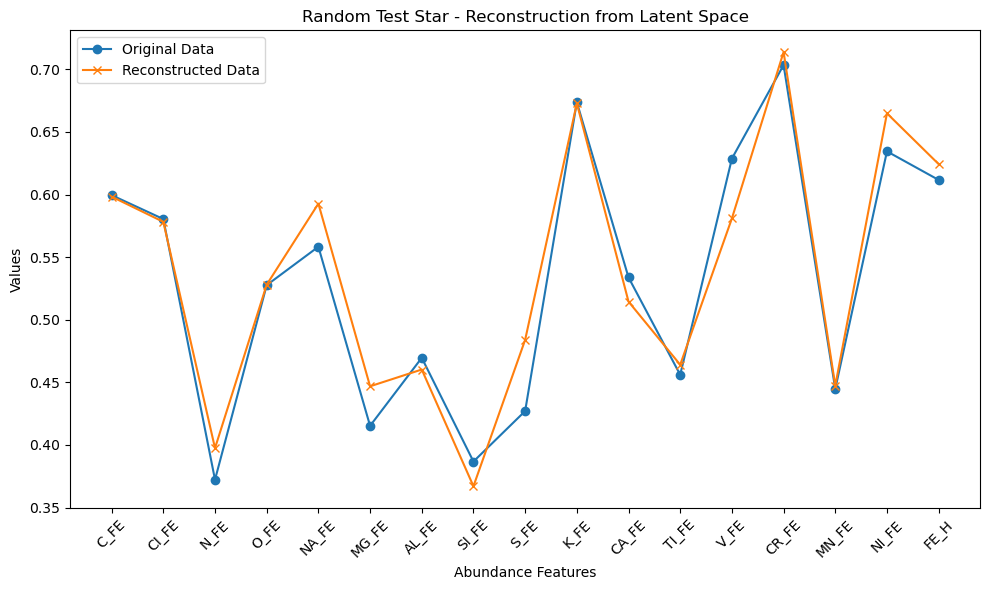

In [84]:
# ------------------------------------------------------------------
# 9) EXAMPLE: RECONSTRUCT A SINGLE RANDOM STAR FROM THE TEST SET
# ------------------------------------------------------------------
import numpy as np

test_size = len(test_dataset)
random_idx = np.random.randint(0, test_size)

x_2d_sample, y_17_sample = test_dataset[random_idx]

model.eval()
with torch.no_grad():
    pred_17_sample = model(x_2d_sample.unsqueeze(0))  # add batch dimension

y_17_sample = y_17_sample.numpy()
pred_17_sample = pred_17_sample.squeeze(0).numpy()

plt.figure(figsize=(10, 6), dpi=100)
plt.plot(range(17), y_17_sample, marker='o', label="Original Data")
plt.plot(range(17), pred_17_sample, marker='x', label="Reconstructed Data")
plt.xticks(range(17), col_names, rotation=45)
plt.xlabel("Abundance Features")
plt.ylabel("Values")
plt.title("Random Test Star - Reconstruction from Latent Space")
plt.legend()
plt.tight_layout()
plt.show()

In [86]:
#------------------------------------------------------------------
# 10) EVALUATION ON THE ENTIRE TEST SET (GLOBAL MSE, EXPLAINED VARIANCE)
# ------------------------------------------------------------------
model.eval()
all_preds = []
all_true = []
with torch.no_grad():
    for x_2d_batch, y_17_batch in test_loader:
        pred_17 = model(x_2d_batch)
        all_preds.append(pred_17.numpy())
        all_true.append(y_17_batch.numpy())

all_preds = np.concatenate(all_preds, axis=0)  # shape [N, 17]
all_true = np.concatenate(all_true, axis=0)    # shape [N, 17]

# Compute the global MSE
mse_global = np.mean((all_preds - all_true) ** 2)

# Compute the total variance (trace of the covariance matrix)
cov_matrix = np.cov(all_true, rowvar=False)
total_variance = np.trace(cov_matrix)

# Compute explained variance
explained_variance = 1 - (mse_global / total_variance)

print("Global MSE on the test set:", mse_global)
print("Total variance (trace of covariance matrix):", total_variance)
print("Explained variance:", explained_variance)


Global MSE on the test set: 0.0014893515
Total variance (trace of covariance matrix): 0.07783793116607526
Explained variance: 0.9808659932087183


Dimension-wise RMSE: [0.02874572 0.03410188 0.06530719 0.03384764 0.05853875 0.02487405
 0.03484088 0.02906567 0.04646813 0.02872176 0.02522401 0.04652858
 0.05048569 0.04048599 0.01779774 0.02934371 0.02576089]
Normalized error per dimension (fraction): [0.03091304 0.03944793 0.07181469 0.04086726 0.06445029 0.03149784
 0.04305739 0.04031705 0.04950142 0.03202675 0.0303778  0.051884
 0.06625871 0.04278235 0.03131025 0.03224992 0.0265411 ]
Normalized error per dimension (%): [3.0913043 3.9447925 7.1814685 4.0867257 6.4450293 3.1497836 4.3057394
 4.0317054 4.9501414 3.2026753 3.03778   5.1883993 6.6258707 4.278235
 3.1310253 3.2249923 2.6541095]


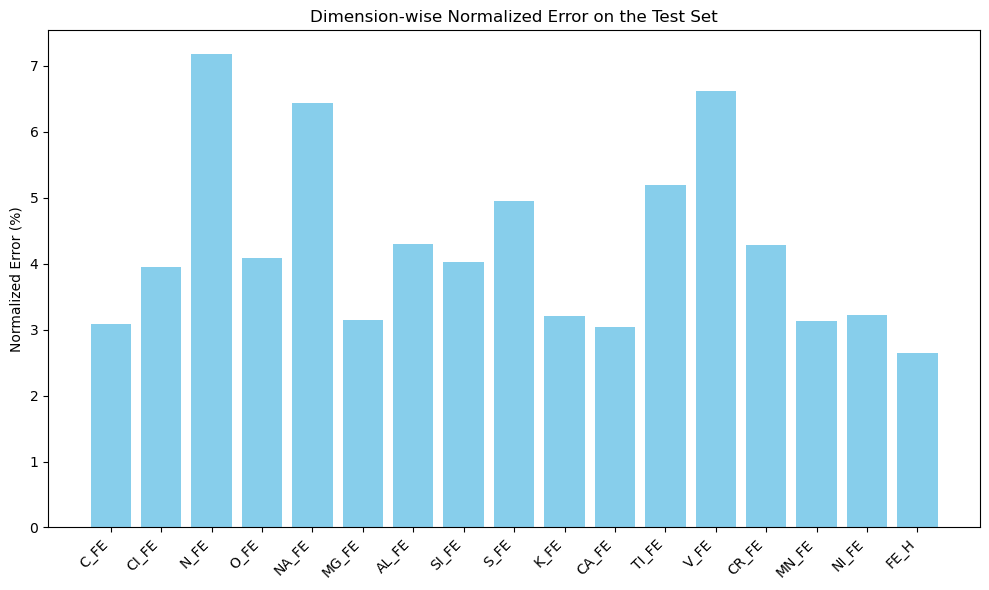

In [87]:
# ------------------------------------------------------------------
# 11) PER-DIMENSION RMSE AND NORMALIZED ERROR
# ------------------------------------------------------------------
# Already have all_true and all_preds from the previous step

# Compute dimension-wise MSE and RMSE
dimwise_mse = np.mean((all_preds - all_true) ** 2, axis=0)
dimwise_rmse = np.sqrt(dimwise_mse)

# Compute the range (max-min) for each dimension
ranges = np.ptp(all_true, axis=0)

# Compute the relative error: RMSE normalized by the variable's range
norm_dimwise_rmse = dimwise_rmse / ranges

# Convert to percentage (1 => 100% error)
norm_dimwise_rmse_percent = norm_dimwise_rmse * 100

# Display results
print("Dimension-wise RMSE:", dimwise_rmse)
print("Normalized error per dimension (fraction):", norm_dimwise_rmse)
print("Normalized error per dimension (%):", norm_dimwise_rmse_percent)

# Optional: bar chart of normalized errors
x_positions = np.arange(len(col_names))
plt.figure(figsize=(10, 6), dpi=100)
plt.bar(x_positions, norm_dimwise_rmse_percent, color='skyblue')
plt.xticks(x_positions, col_names, rotation=45, ha='right')
plt.ylabel("Normalized Error (%)")
plt.title("Dimension-wise Normalized Error on the Test Set")
plt.tight_layout()
plt.show()


In [88]:
# ------------------------------------------------------------------
# 12) SCATTER PLOTS: ORIGINAL VS. RECONSTRUCTED FOR EACH DIMENSION
# ------------------------------------------------------------------
import torch
import numpy as np

model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for x_2d_batch, y_17_batch in test_loader:
        pred_17 = model(x_2d_batch)
        all_preds.append(pred_17.numpy())
        all_true.append(y_17_batch.numpy())

all_preds = np.concatenate(all_preds, axis=0)  # shape [N, 17]
all_true = np.concatenate(all_true, axis=0)    # shape [N, 17]


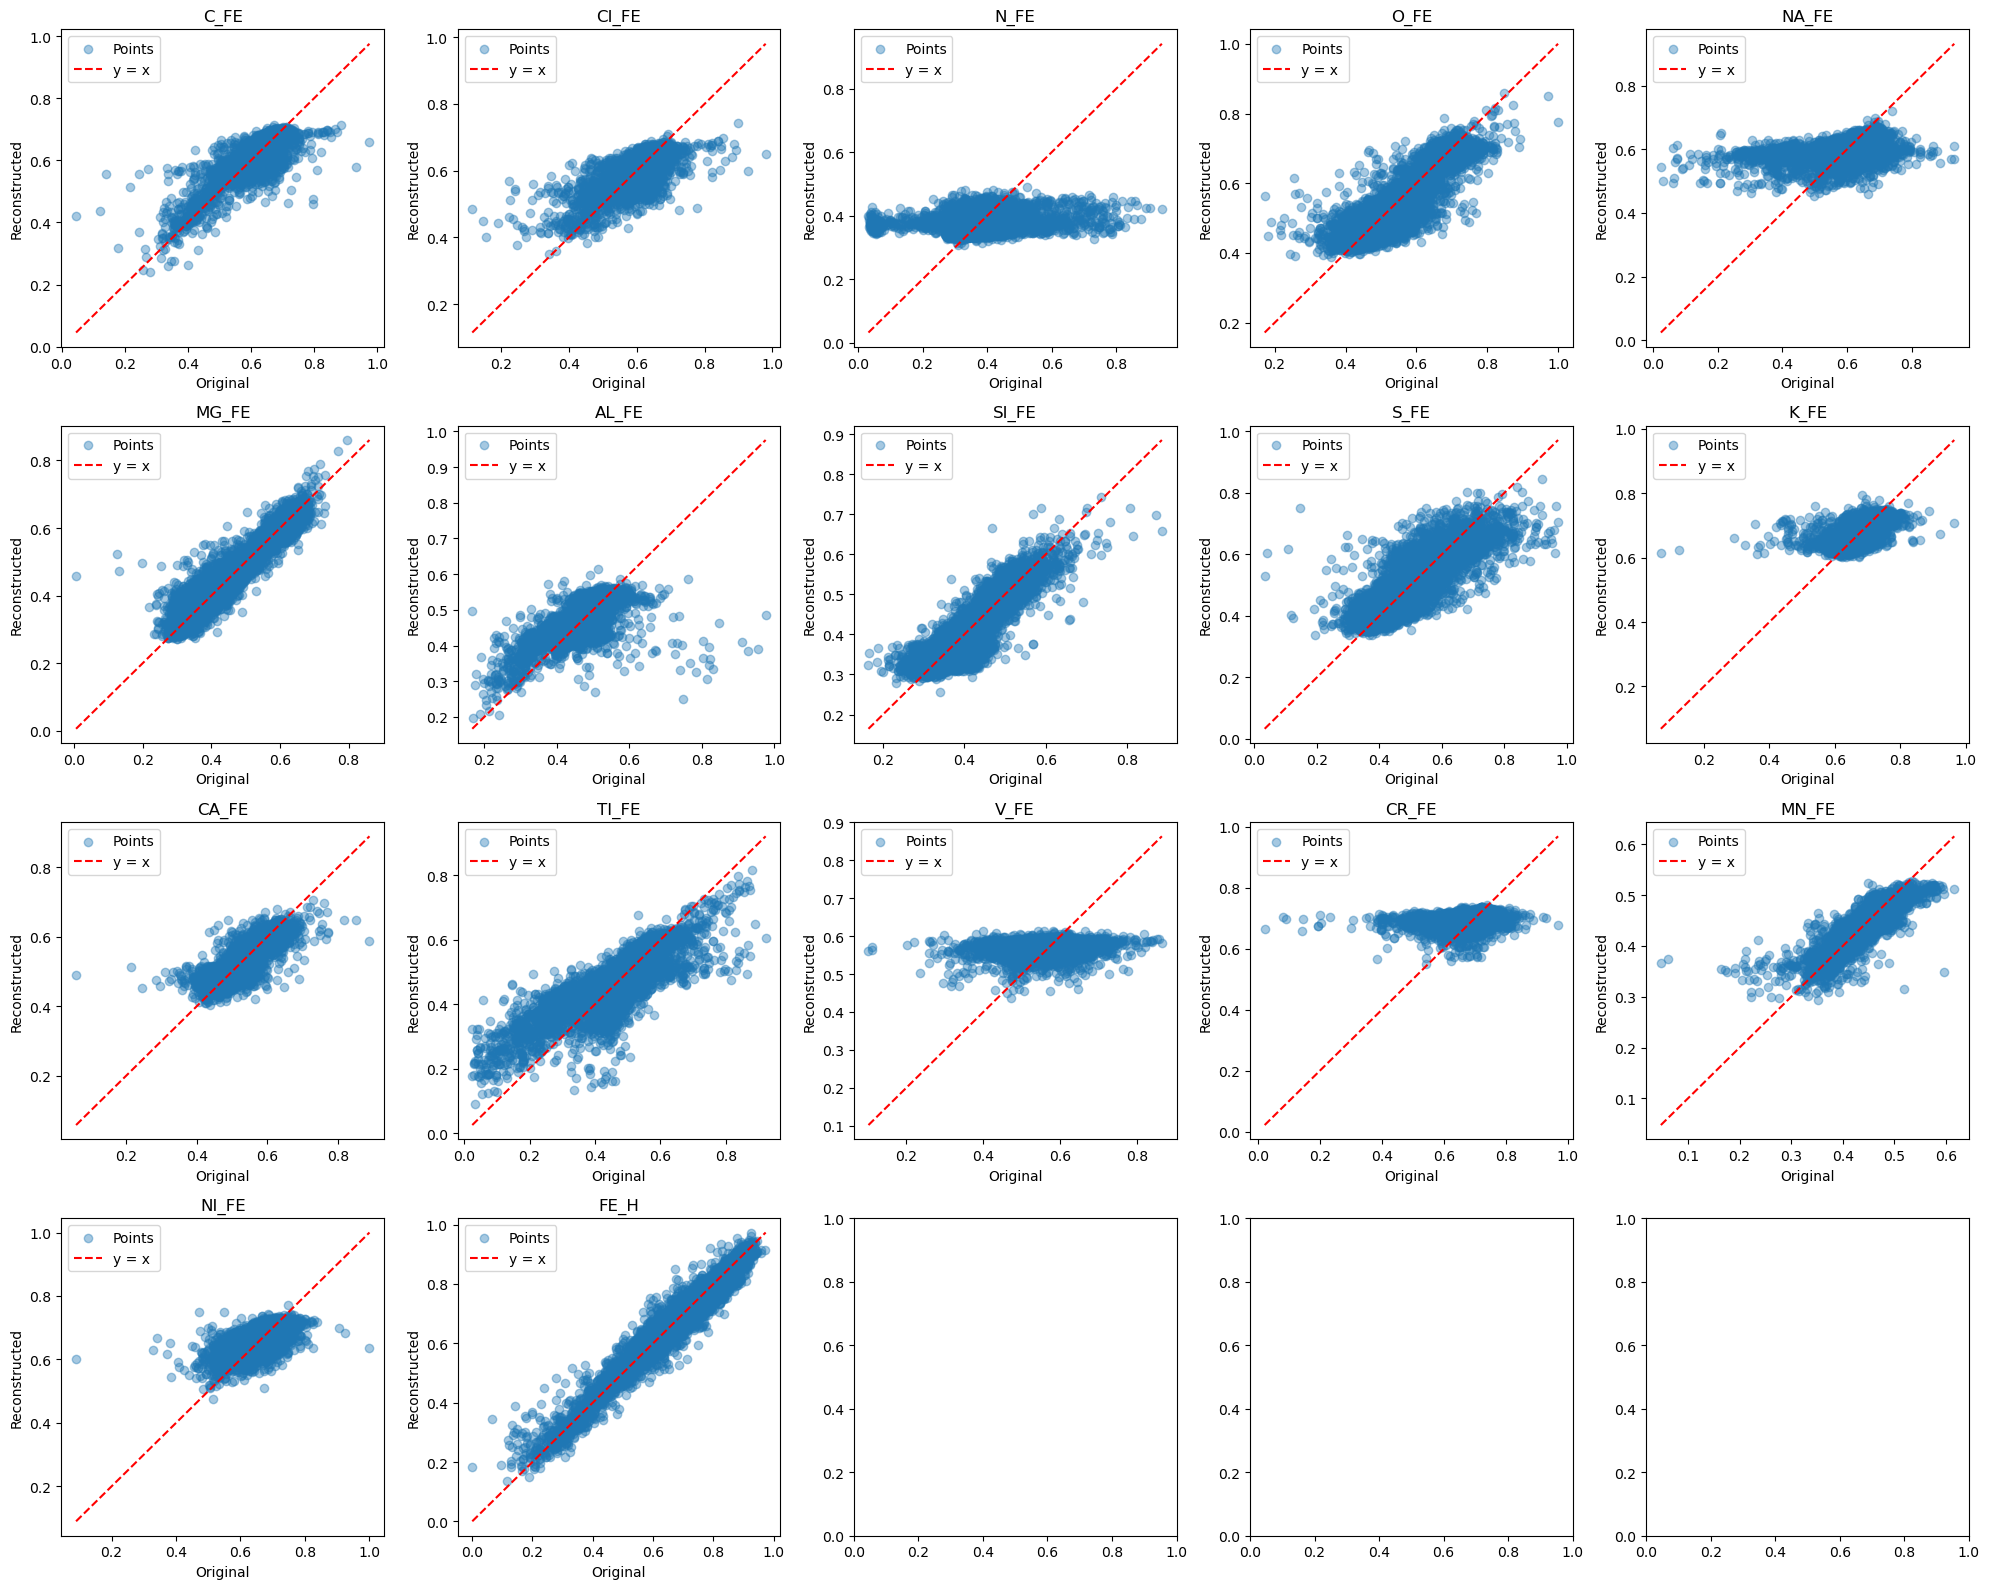

In [89]:
import matplotlib.pyplot as plt

num_dims = all_true.shape[1]  # should be 17
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(20, 16))
axes = axes.flatten()

for i in range(num_dims):
    axes[i].scatter(all_true[:, i], all_preds[:, i], alpha=0.4, label='Points')
    # Add the diagonal y=x for reference
    min_val = min(all_true[:, i].min(), all_preds[:, i].min())
    max_val = max(all_true[:, i].max(), all_preds[:, i].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

    axes[i].set_title(col_names[i])
    axes[i].set_xlabel("Original")
    axes[i].set_ylabel("Reconstructed")
    axes[i].legend()

# If you have fewer than 20 dimensions, the remaining subplots will be empty
plt.tight_layout()
plt.show()

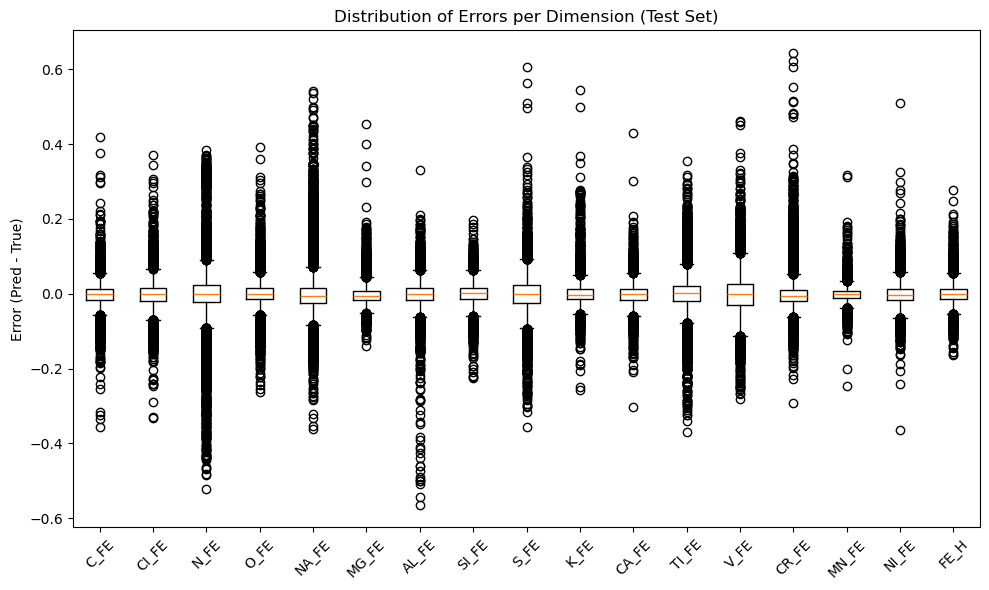

In [91]:
# ------------------------------------------------------------------
# 13) BOX PLOT OF ERRORS PER DIMENSION
# ------------------------------------------------------------------
errors = all_preds - all_true

plt.figure(figsize=(10, 6))
plt.boxplot(errors, tick_labels=col_names, vert=True)
plt.xticks(rotation=45)
plt.ylabel("Error (Pred - True)")
plt.title("Distribution of Errors per Dimension (Test Set)")
plt.tight_layout()
plt.show()